# Exploratory Data Analysis (EDA) - Kualitas Udara (PM2.5)
Notebook ini berisi analisis data historis kualitas udara dan parameter cuaca untuk memahami faktor-faktor yang mempengaruhi tingkat polusi PM2.5. Grafik dan visualisasi dari notebook ini sangat cocok untuk dimasukkan ke dalam file README.md sebagai laporan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Memuat Dataset
Kita memuat data dari `data_polusi_lokal.csv` yang berisi fitur parameter cuaca dan target polusi.

In [2]:
df = pd.read_csv('data_polusi_lokal.csv')
display(df.head())
print("\nInfo Dataset:")
df.info()

,datetime,pm25,temperature,humidity,wind_speed,latitude,longitude,location,hour,day_of_week,month
0,2025-04-10 08:00:00,20.4,28.5,78,2.5,-5.45,105.2667,Bandar Lampung,8,3,4
1,2025-04-10 09:00:00,12.3,29.7,71,1.8,-5.45,105.2667,Bandar Lampung,9,3,4
2,2025-04-10 10:00:00,10.1,30.0,71,2.1,-5.45,105.2667,Bandar Lampung,10,3,4
3,2025-04-10 11:00:00,10.7,30.8,70,0.6,-5.45,105.2667,Bandar Lampung,11,3,4
4,2025-04-10 12:00:00,10.4,31.2,69,2.8,-5.45,105.2667,Bandar Lampung,12,3,4



Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10000 non-null  object 
 1   pm25         10000 non-null  float64
 2   temperature  10000 non-null  float64
 3   humidity     10000 non-null  int64  
 4   wind_speed   10000 non-null  float64
 5   latitude     10000 non-null  float64
 6   longitude    10000 non-null  float64
 7   location     10000 non-null  object 
 8   hour         10000 non-null  int64  
 9   day_of_week  10000 non-null  int64  
 10  month        10000 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 859.5+ KB


## 2. Distribusi Target (PM2.5)
Melihat bagaimana sebaran nilai PM2.5 di dalam dataset.

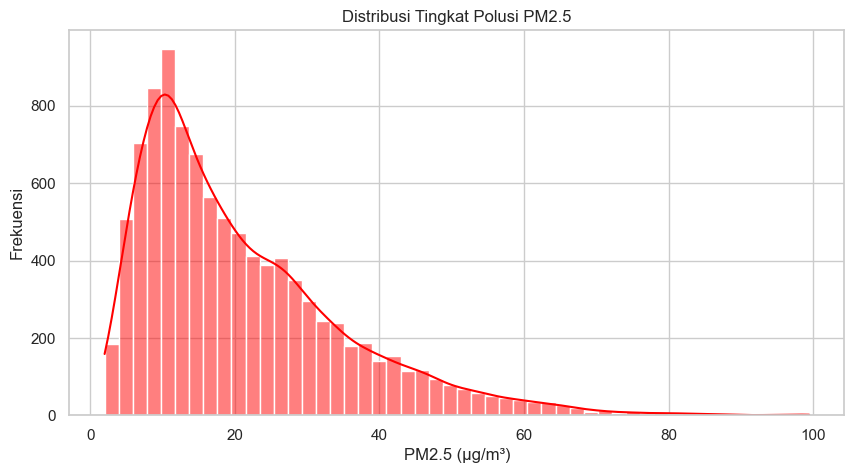

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['pm25'], bins=50, kde=True, color='red')
plt.title('Distribusi Tingkat Polusi PM2.5')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frekuensi')
plt.show()

## 3. Rata-rata PM2.5 Berdasarkan Jam
Menganalisis pada jam berapa polusi cenderung paling tinggi.

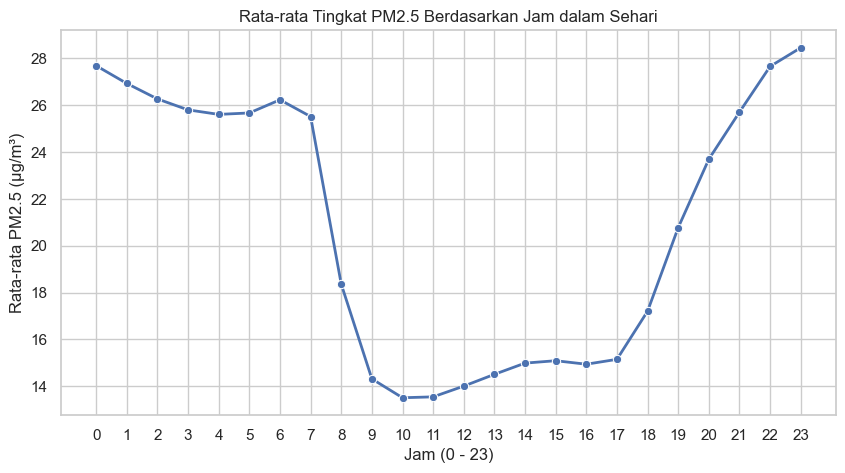

In [4]:
hourly_pm25 = df.groupby('hour')['pm25'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_pm25, x='hour', y='pm25', marker='o', color='b', linewidth=2)
plt.title('Rata-rata Tingkat PM2.5 Berdasarkan Jam dalam Sehari')
plt.xlabel('Jam (0 - 23)')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

## 4. Analisis Korelasi (Fitur Cuaca vs PM2.5)
Menggunakan *Heatmap* untuk melihat variabel (suhu, kelembapan, kecepatan angin) yang paling berkorelasi dengan polusi.

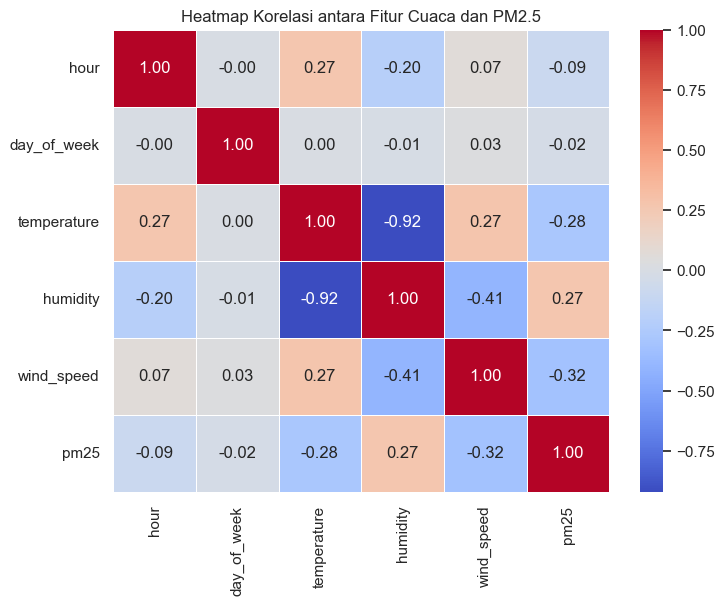

In [5]:
features = ['hour', 'day_of_week', 'temperature', 'humidity', 'wind_speed', 'pm25']
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi antara Fitur Cuaca dan PM2.5')
plt.show()

## 5. Kecepatan Angin vs PM2.5
Melihat apakah kecepatan angin yang tinggi membantu mengurangi konsentrasi polusi PM2.5.

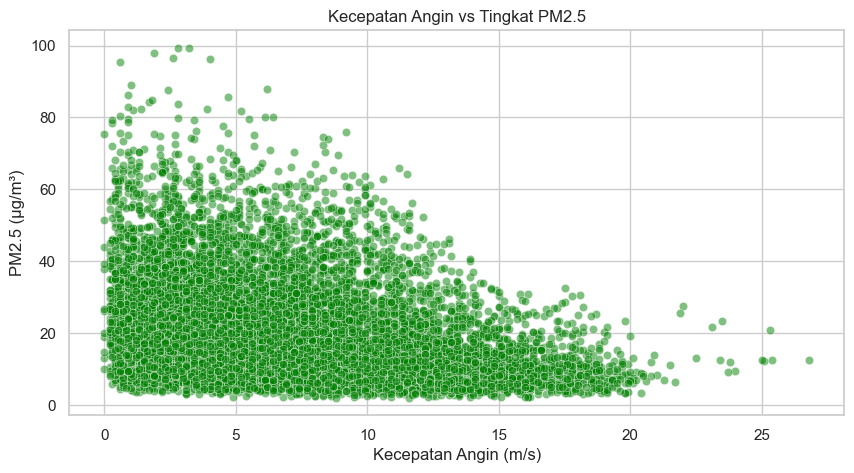

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='wind_speed', y='pm25', alpha=0.5, color='green')
plt.title('Kecepatan Angin vs Tingkat PM2.5')
plt.xlabel('Kecepatan Angin (m/s)')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()